# Time-dependent toy example

Two illustrative dispatch problems on the same toy database, demonstrating the
time-indexed formulation in `pulpo.utils.time_extension`:

1. **One day, hourly resolution** — bell-shaped solar peaking at noon, demand
   with morning and evening peaks. Battery is used for *intra-day* shifting.
2. **Two weeks, daily resolution** — variable solar (sunny days, cloudy days,
   a few breaks in the overcast week) and a weekday/weekend demand pattern.
   Battery is used for *multi-day* propagation across the horizon.

## Storage logic at a glance

Each storage technology is split into four virtual activities sharing one
intermediate product (the *charge product*):

| Activity | Ref. product | Inputs | Role |
|---|---|---|---|
| `CHARGE` | `charge_product` | 1 kWh electricity | Pumps electricity into storage |
| `HOLD` | `charge_product` | 1 unit `holdtm1_product` | In-step carrier of stored energy |
| `DISCHARGE` | `electricity, battery` | 1 unit `charge_product` | Releases electricity from storage |
| `HOLD t-1` | `holdtm1_product` | — (phantom) | Bridges *across* timesteps via `K` |

`CHARGE` and `HOLD` produce the *same* product `charge_product`; PULPO's
`choices` mechanism unifies them into a single virtual supplier feeding
`DISCHARGE`. The phantom `HOLD t-1` produces `holdtm1_product`; its scaling at
$t$ is locked at 0, but the engine adds a carry-over supply equal to
$K \cdot (\text{charge\_product produced at } t{-}1)$. Because
`holdtm1_product` is a stored product, its time-balance is the inequality

$$
SOC_t \;\le\; K \cdot \bigl(SOC_{t-1} + \text{charged}_{t-1} - \text{discharged}_{t-1}\bigr).
$$

The storage spec passed to PULPO is

```python
storage = [(battery_holdtm1, "charge_product", K)]
#          (target_product,    source_product, factor)
```

`K = 1.0` is lossless, `K < 1.0` lossy, `K = None` disables storage.


In [1]:
import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pulpo import pulpo_time
from pulpo.datasets.elec_time_database import (
    setup_elec_time_db,
    PROJECT_NAME, DB_NAME,
    SOLAR_KEY, COAL_KEY,
    BATTERY_CHARGE_KEY, BATTERY_HOLD_KEY,
    BATTERY_DISCHARGE_KEY, BATTERY_HOLDTM1_KEY,
    CHARGE_PRODUCT_CHOICE,
)

setup_elec_time_db()
bd.projects.set_current(PROJECT_NAME)
db = bd.Database(DB_NAME)

solar     = next(a for a in db if a.key == SOLAR_KEY)
coal      = next(a for a in db if a.key == COAL_KEY)
charge    = next(a for a in db if a.key == BATTERY_CHARGE_KEY)
hold      = next(a for a in db if a.key == BATTERY_HOLD_KEY)
discharge = next(a for a in db if a.key == BATTERY_DISCHARGE_KEY)
holdtm1   = next(a for a in db if a.key == BATTERY_HOLDTM1_KEY)

GWP100 = str(("GWP", "100a"))


[elec_time_toy] project='elec_time_toy', db='elec_time_toy_db', activities=6, methods=[('GWP', '100a')]


## Shared helpers

Both examples reuse the same scenario solver and dispatch plot. Each scenario
is parameterised by `K` (round-trip retention factor) and the per-step
input dictionaries.

In [2]:
def build_inputs(time_steps, solar_cap, demand_kwh):
    """Assemble (choices, demand, upper_limit, lower_limit) for the toy DB."""
    choices = {
        "electricity":         {solar: 1e6, coal: 1e6, discharge: 1e6},
        CHARGE_PRODUCT_CHOICE: {charge: 1e6, hold: 1e6},
    }
    upper_limit = {
        t: {
            solar: solar_cap[t],
            coal: 1e6,
            charge: 1e6,
            hold: 1e6,
            # battery starts empty -> nothing to discharge at t=0
            discharge: 0.0 if t == time_steps[0] else 1e6,
            holdtm1: 0.0,  # phantom
        }
        for t in time_steps
    }
    # battery flows must be non-negative (default lower bound is -inf)
    lower_limit = {t: {charge: 0.0, hold: 0.0, discharge: 0.0} for t in time_steps}
    demand = {t: {"electricity": demand_kwh[t]} for t in time_steps}
    return choices, demand, upper_limit, lower_limit


def solve_scenario(label, *, K, time_steps, step_labels,
                   solar_cap, demand_kwh):
    choices, demand, upper_limit, lower_limit = build_inputs(
        time_steps, solar_cap, demand_kwh)
    storage_spec = [(holdtm1, CHARGE_PRODUCT_CHOICE, K)] if K is not None else None
    w = pulpo_time.PulpoOptimizerTime(PROJECT_NAME, DB_NAME, {GWP100: 1}, ".")
    w.get_lci_data()
    w.instantiate(
        choices=choices, demand=demand,
        upper_limit=upper_limit, lower_limit=lower_limit,
        time_steps=time_steps, storage=storage_spec,
    )
    w.solve()
    pmap = w.lci_data["process_map"]
    df = pd.DataFrame(
        {name: [w.instance.scaling_vector[t, pmap[a.key]].value for t in time_steps]
         for name, a in [("solar", solar), ("coal", coal),
                         ("charge", charge), ("hold", hold),
                         ("discharge", discharge)]},
        index=step_labels,
    )
    df["co2"] = [w.instance.impacts[t, GWP100].value for t in time_steps]
    df.attrs.update(label=label, K=K, total_co2=float(df["co2"].sum()))
    return df


def stored_energy_series(df, K):
    """SOC entering each step: SOC_t = K*(SOC_{t-1} + charge_{t-1} - discharge_{t-1})."""
    if K is None:
        return [0.0] * len(df)
    soc = [0.0]
    for t in range(len(df) - 1):
        soc.append(K * (soc[-1] + df["charge"].iloc[t] - df["discharge"].iloc[t]))
    return soc


def plot_dispatch(dfs, time_steps, step_labels, demand_kwh,
                  separators=(), title=""):
    x = np.arange(len(time_steps))
    fig, axes = plt.subplots(len(dfs), 1, figsize=(11, 3.0 * len(dfs)),
                             sharex=True)
    if len(dfs) == 1:
        axes = [axes]
    for ax, df in zip(axes, dfs):
        bottoms = np.zeros(len(time_steps))
        for col, color, lab in [("solar",     "#f4a826", "solar"),
                                ("discharge", "#9b59b6", "discharge (out)"),
                                ("coal",      "#5d5d5d", "coal")]:
            v = df[col].values
            ax.bar(x, v, bottom=bottoms, label=lab, color=color, edgecolor="white")
            bottoms = bottoms + v
        ax.bar(x, -df["charge"].values, color="none", edgecolor="#2ca02c",
               hatch="//", linewidth=1.0, label="charge (into battery)")
        if df.attrs["K"] is not None:
            ax2 = ax.twinx()
            ax2.plot(x, stored_energy_series(df, df.attrs["K"]),
                     "o--", color="#2ca02c", markersize=4,
                     label="state of charge")
            ax2.set_ylabel("SOC [kWh]", color="#2ca02c")
            ax2.tick_params(axis='y', labelcolor="#2ca02c")
        ax.plot(x, [demand_kwh[t] for t in time_steps], "k_", markersize=10,
                markeredgewidth=2, label="demand")
        for s in separators:
            ax.axvline(s, color="k", linestyle=":", linewidth=1)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title(f"{df.attrs['label']}  -  CO2 = {df.attrs['total_co2']:.1f} kg")
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylabel("kWh\n(- charge | + supply +)")
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(step_labels, rotation=45, ha="right")
    axes[0].legend(loc="upper right", fontsize=8, ncol=2)
    if title:
        fig.suptitle(title)
    fig.tight_layout(); plt.show()


## Example 1 — One day, hourly resolution

24 hourly steps. **Solar** follows a bell curve peaking at 120 kWh at noon (zero
before sunrise and after sunset). **Demand** has the classic double-peak shape:
quiet at night, a morning ramp, a midday plateau, and a strong evening peak.

The storage role here is short-term: charge midday surplus to cover the
evening peak.

In [3]:
# 24 hourly steps; bell-shaped solar, double-peak demand
time_steps_h  = list(range(24))
step_labels_h = [f"{t:02d}h" for t in time_steps_h]

solar_cap_h  = {t: v for t, v in enumerate([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 31.1, 60.0, 84.9, 103.9, 115.9, 120.0, 115.9, 103.9, 84.9, 60.0, 31.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])}
demand_kwh_h = {t: v for t, v in enumerate([25, 20, 20, 20, 25, 35, 55, 70, 70, 55, 45, 40, 40, 40, 45, 55, 65, 75, 80, 75, 60, 45, 35, 30])}


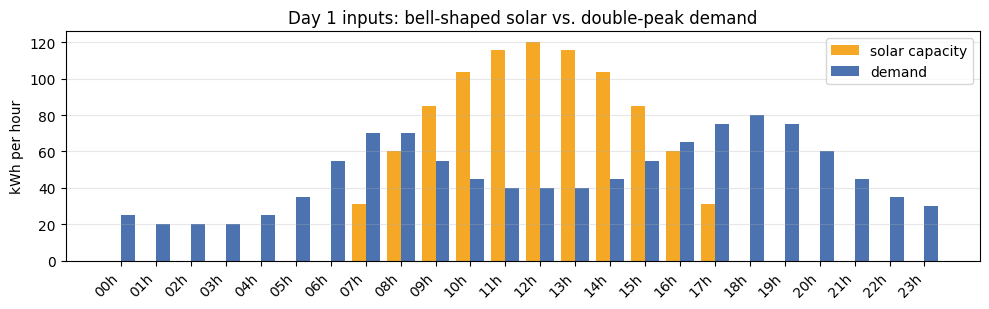

In [4]:
x = np.arange(24)
width = 0.4
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(x - width/2, [solar_cap_h[t]  for t in time_steps_h], width,
       label="solar capacity", color="#f4a826")
ax.bar(x + width/2, [demand_kwh_h[t] for t in time_steps_h], width,
       label="demand",          color="#4c72b0")
ax.set_xticks(x); ax.set_xticklabels(step_labels_h, rotation=45, ha="right")
ax.set_ylabel("kWh per hour")
ax.set_title("Day 1 inputs: bell-shaped solar vs. double-peak demand")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()


In [5]:
kwargs_h = dict(time_steps=time_steps_h, step_labels=step_labels_h,
                solar_cap=solar_cap_h, demand_kwh=demand_kwh_h)
df_h_none  = solve_scenario("no battery",            K=None, **kwargs_h)
df_h_lossy = solve_scenario("battery (K = 0.95)",    K=0.95, **kwargs_h)
df_h_ideal = solve_scenario("ideal battery (K=1.0)", K=1.0,  **kwargs_h)

for df in (df_h_none, df_h_lossy, df_h_ideal):
    print(f"  {df.attrs['label']:25s}  total CO2 = {df.attrs['total_co2']:7.2f} kg")


Creating time-indexed instance
Time-indexed instance created
optimal solution found:  622.8
Creating time-indexed instance


Time-indexed instance created
optimal solution found:  332.8151255356928
Creating time-indexed instance
Time-indexed instance created
optimal solution found:  248.9
  no battery                 total CO2 =  622.80 kg
  battery (K = 0.95)         total CO2 =  332.82 kg
  ideal battery (K=1.0)      total CO2 =  248.90 kg


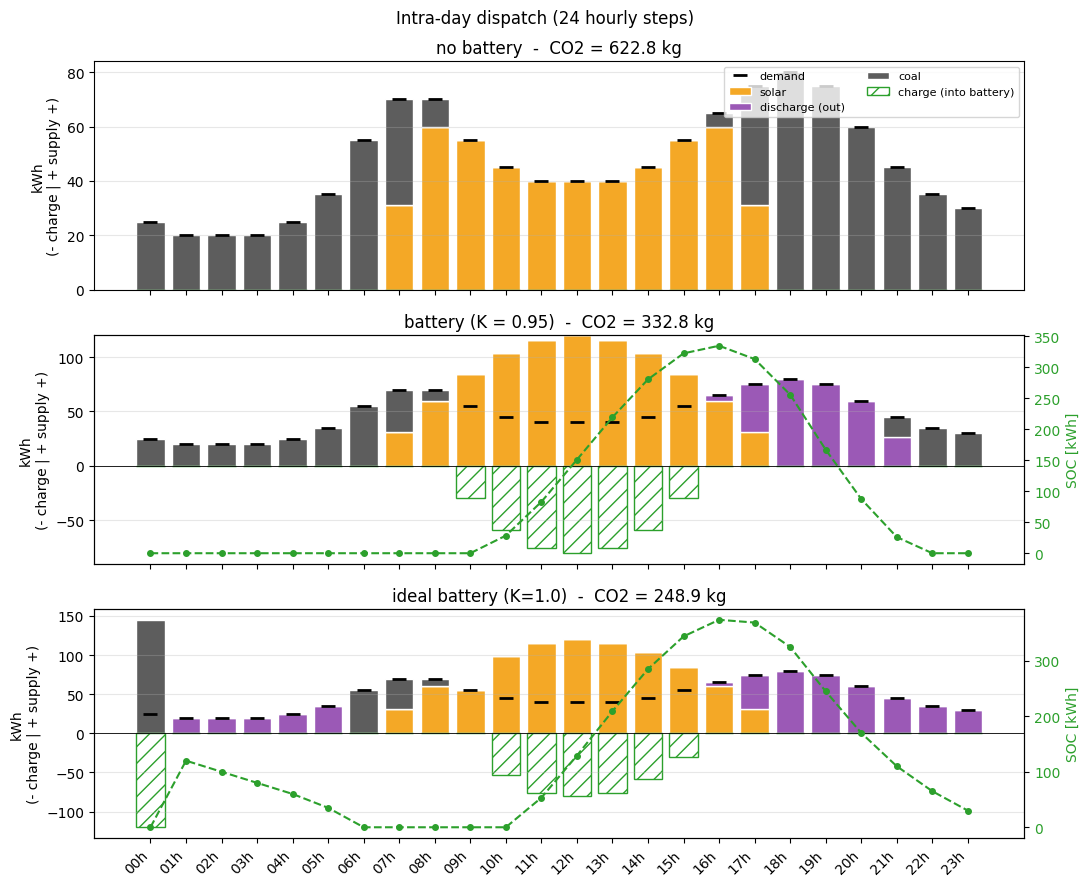

In [6]:
plot_dispatch([df_h_none, df_h_lossy, df_h_ideal],
              time_steps_h, step_labels_h, demand_kwh_h,
              title="Intra-day dispatch (24 hourly steps)")


## Example 2 — Two weeks, daily resolution

14 daily steps. **Solar** mostly follows a sunny / overcast pattern with
realistic variability: a partly cloudy day in week 1 and two short sunny breaks
in week 2. **Demand** drops on weekends (days 5–6 and 12–13).

The storage role here is *multi-step propagation*: the optimizer must transport
week-1 surplus across many days to cover week-2 demand — feasible only because
`HOLD` recycles `charge_product` from one step to the next, paying a factor of
`K` each time.

In [7]:
# 14 daily steps; varied solar + weekday/weekend demand
time_steps_d  = list(range(14))
step_labels_d = [f"day {t}" for t in time_steps_d]

solar_cap_d  = {t: v for t, v in enumerate([120, 110, 95, 40, 100, 130, 100, 10, 5, 50, 5, 10, 30, 5])}
demand_kwh_d = {t: v for t, v in enumerate([50, 55, 60, 50, 45, 30, 30, 55, 60, 65, 60, 50, 35, 35])}


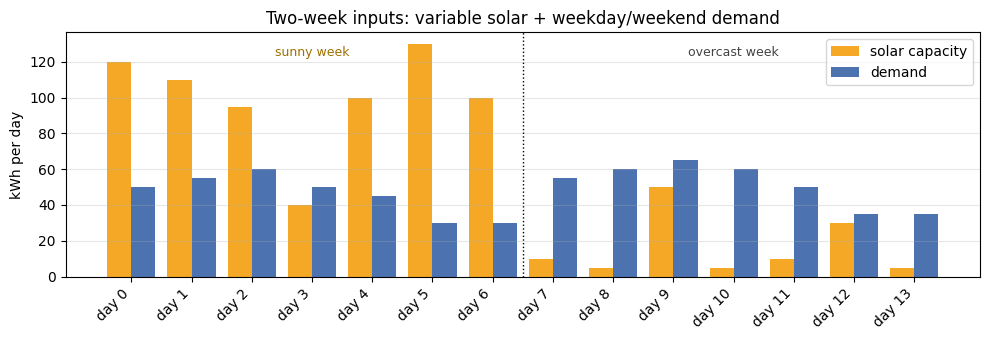

In [8]:
x = np.arange(14)
width = 0.4
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(x - width/2, [solar_cap_d[t]  for t in time_steps_d], width,
       label="solar capacity", color="#f4a826")
ax.bar(x + width/2, [demand_kwh_d[t] for t in time_steps_d], width,
       label="demand",          color="#4c72b0")
ax.axvline(6.5, color="k", linestyle=":", linewidth=1)
ymax = max(max(solar_cap_d.values()), max(demand_kwh_d.values()))
ax.text(3.0,  ymax * 0.95, "sunny week",    ha="center", fontsize=9, color="#a07000")
ax.text(10.0, ymax * 0.95, "overcast week", ha="center", fontsize=9, color="#444")
ax.set_xticks(x); ax.set_xticklabels(step_labels_d, rotation=45, ha="right")
ax.set_ylabel("kWh per day")
ax.set_title("Two-week inputs: variable solar + weekday/weekend demand")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()


In [9]:
kwargs_d = dict(time_steps=time_steps_d, step_labels=step_labels_d,
                solar_cap=solar_cap_d, demand_kwh=demand_kwh_d)
df_d_none  = solve_scenario("no battery",             K=None, **kwargs_d)
df_d_lossy = solve_scenario("battery (K = 0.85)",     K=0.85, **kwargs_d)
df_d_ideal = solve_scenario("ideal battery (K = 1.0)",K=1.0,  **kwargs_d)

for df in (df_d_none, df_d_lossy, df_d_ideal):
    print(f"  {df.attrs['label']:30s}  total CO2 = {df.attrs['total_co2']:7.2f} kg")


Creating time-indexed instance
Time-indexed instance created
optimal solution found:  255.0
Creating time-indexed instance
Time-indexed instance created
optimal solution found:  75.61739504764356
Creating time-indexed instance
Time-indexed instance created
optimal solution found:  0.0
  no battery                      total CO2 =  255.00 kg
  battery (K = 0.85)              total CO2 =   75.62 kg
  ideal battery (K = 1.0)         total CO2 =    0.00 kg


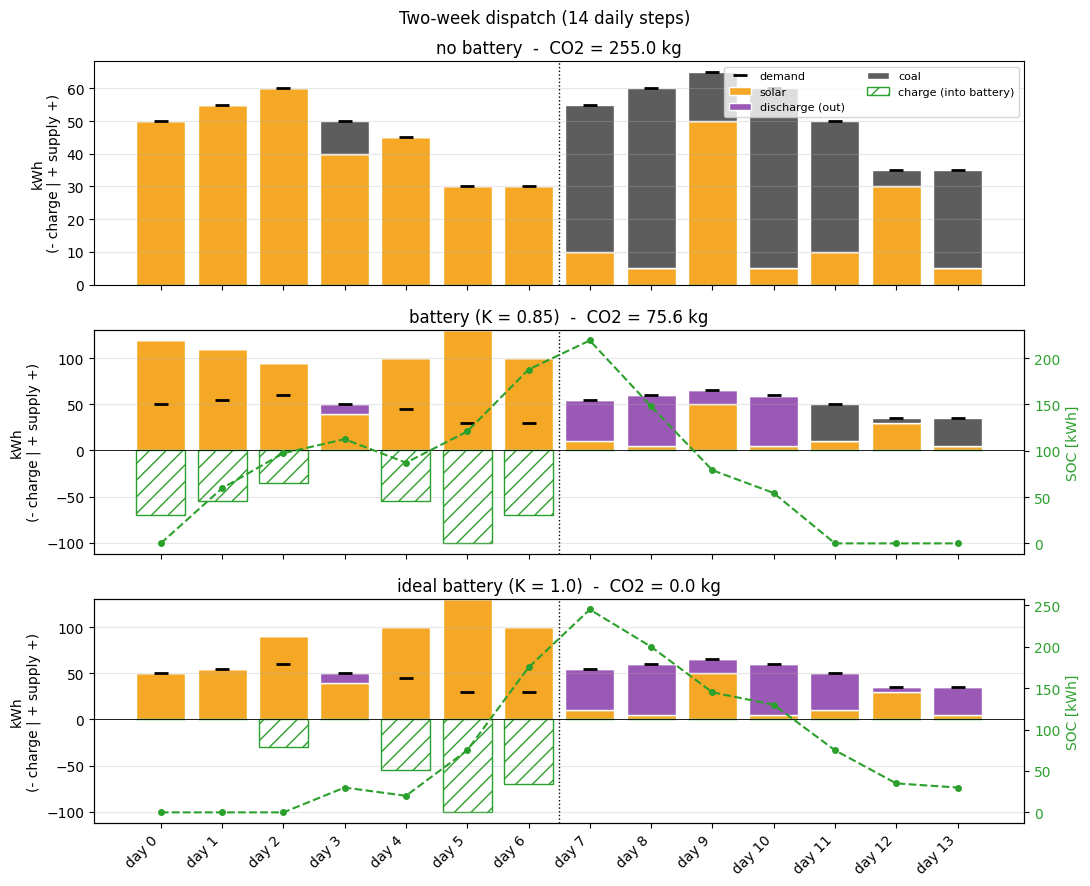

In [10]:
plot_dispatch([df_d_none, df_d_lossy, df_d_ideal],
              time_steps_d, step_labels_d, demand_kwh_d,
              separators=(6.5,),
              title="Two-week dispatch (14 daily steps)")
